# Peaks, fit, subtract, repeat: the Crystallizer and the density fit in a loop (α-Li₂SO₄)

The [companion notebook](crystallizer_density.ipynb) runs the Crystallizer and the density
fit once each, and a person does the rest. The Crystallizer proposes Fm-3m and a Li site on
8c. A Gaussian mixture is fitted on that site. Someone looks at the residual, spots the
octahedral 4b site in it, adds it by hand and fits again. Every step after the first needs
someone reading a map.

`crystallize_density_loop` automates that, one species at a time:

1. **Peaks → symmetry.** The [Crystallizer][gemdat.crystallizer.Crystallizer] takes the
   peaks of the density and the time-averaged framework, and fits the highest space group
   they support.
2. **Symmetry → density.** `from_crystallizer` turns that fit into symmetry operations and
   one starting site per orbit, in the trajectory's own basis. The density is folded and
   symmetrised with those operations.
3. **Fit.** `fit_density_model` refines one Gaussian per orbit: its width and occupancy
   fraction.
4. **Subtract.** The fitted Gaussians are subtracted from the symmetrised density. A density
   cannot be negative, so the leftover is clipped at zero: it is only where the observed
   density *stands above* the model.
5. **Repeat.** The leftover goes back to step 1. This time the Crystallizer sees only what
   the sites so far did not explain: a site hidden under a broad one, or under the tails of
   those already fitted.

A species stops by itself when a round explains less than `min_explained` (5 %) of its
density, when the group found would need more than `max_orbits` (12) orbits (noise
crystallizes as P1, one orbit per peak), or after `max_rounds`. After the call you do not
make any choices; the plots below are drawn afterwards from what it returns.

The data is T. Famprikis's ab initio MD run of plastic-crystal α-Li₂SO₄: a 2×2×2 supercell
of the Fm-3m cell, 224 atoms, at 1000 K. The cache (`vasprun.xml.12a3e781.cache`, 435 MB) is
not part of the repository, so point `DATA` at your copy.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import map_coordinates

from gemdat import Trajectory
from gemdat.density_crystallography import (
    crystallize_density_loop,
    fit_density_model,
    fold_supercell,
    site_free_directions,
    wyckoff_orbit,
)

DATA = Path('../../local/li2so4/vasprun.xml.12a3e781.cache')
EQUILIBRATION_CUTOFF = 6007  # frames dropped as equilibration, as in the reference scripts
RESOLUTION = 0.16  # Å, for the Crystallizer and the density grids alike
SUPERCELL = (2, 2, 2)
ATOMS_PER_CELL = {'S': 4, 'Li': 8, 'O': 16}  # conventional Fm-3m cell, Z = 4

The plot helpers are the same as in the companion notebook. Densities use a single-hue
scale. Residuals use a diverging scale that is grey at zero: blue where the observed
density is above the model, orange where the model is above it.

In [2]:
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e3e2dd'

SEQ = LinearSegmentedColormap.from_list(
    'seq', ['#fcfcfb', '#d6e5f7', '#8db8ec', '#2a78d6', '#154a8c', '#0b2748']
)
DIV = LinearSegmentedColormap.from_list(
    'div', ['#7a2e0e', ORANGE, '#f4c7b0', '#e8e7e3', '#b5d0f2', BLUE, '#0f3a6e']
)

plt.rcParams.update(
    {
        'figure.dpi': 100,
        'font.size': 10,
        'axes.edgecolor': MUTED,
        'axes.labelcolor': INK,
        'axes.titlecolor': INK,
        'axes.titlesize': 10,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.color': GRID,
        'grid.linewidth': 0.6,
        'xtick.color': MUTED,
        'ytick.color': MUTED,
        'legend.frameon': False,
        'lines.linewidth': 2,
        'axes.axisbelow': True,
    }
)


def sample(grid, frac):
    # Interpolate a periodic grid at fractional coordinates frac (..., 3).
    idx = np.mod(frac, 1.0) * np.array(grid.shape) - 0.5
    return map_coordinates(grid, np.moveaxis(idx, -1, 0), order=1, mode='grid-wrap')


def plane(grid, origin, e1, e2, n=176):
    # Density on origin + u*e1 + v*e2 for u, v in [0, 1), as an imshow image (rows = v).
    t = (np.arange(n) + 0.5) / n
    u, v = np.meshgrid(t, t, indexing='ij')
    frac = np.asarray(origin) + u[..., None] * np.asarray(e1) + v[..., None] * np.asarray(e2)
    return sample(grid, frac).T


def show(
    ax,
    image,
    *,
    extent=(0, 1, 0, 1),
    cmap=SEQ,
    vmin=None,
    vmax=None,
    title='',
    labels=('x', 'y'),
):
    im = ax.imshow(image, origin='lower', extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set(title=title, xlabel=labels[0], ylabel=labels[1])
    ax.grid(False)
    return im


DIAGONAL_PLANE = dict(
    origin=(0, 0, 0),
    e1=(1, 1, 0),
    e2=(0, 0, 1),
    extent=(0, np.sqrt(2), 0, 1),
    labels=('[110] (a)', '[001] (a)'),
)


def compare_maps(
    observed, model, *, origin, e1, e2, title, labels=('x', 'y'), extent=(0, 1, 0, 1)
):
    # Observed | model | observed - model on one plane, both grids normalised to sum 1.
    o = plane(observed / observed.sum(), origin, e1, e2)
    m = plane(model / model.sum(), origin, e1, e2)
    vmax = max(o.max(), m.max())
    rmax = np.abs(o - m).max()
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.9), layout='constrained')
    show(axs[0], o, vmin=0, vmax=vmax, title='observed', labels=labels, extent=extent)
    im = show(axs[1], m, vmin=0, vmax=vmax, title='model', labels=labels, extent=extent)
    fig.colorbar(im, ax=axs[:2], shrink=0.85, label='density (normalised)')
    im = show(
        axs[2],
        o - m,
        cmap=DIV,
        vmin=-rmax,
        vmax=rmax,
        title='observed − model',
        labels=labels,
        extent=extent,
    )
    fig.colorbar(im, ax=axs[2], shrink=0.85, label='residual')
    fig.suptitle(title, color=INK)
    return fig


def line(grid, start, stop, n=241):
    t = np.linspace(0, 1, n)
    frac = np.asarray(start) + t[:, None] * (np.asarray(stop) - np.asarray(start))
    return t, sample(grid, frac)


def sites_table(result):
    # One row per refined orbit; site occupancy = atoms per cell * fraction / multiplicity.
    return pd.DataFrame(
        [
            {
                'specie': site.specie,
                'multiplicity': site.multiplicity,
                'position': tuple(float(v) for v in np.round(site.position, 4) % 1),
                'density fraction': round(site.occupancy, 4),
                'site occupancy': round(
                    ATOMS_PER_CELL[site.specie] * site.occupancy / site.multiplicity, 4
                ),
                'U_iso (Å²)': round(site.u_iso, 4),
                'split (Å)': None if site.displacement is None else round(site.displacement, 3),
            }
            for site in result.sites
        ]
    )

## 1. The trajectory

Load the cache, correct the drift on the sulfur atoms and drop the first 6007 frames as
equilibration, the same starting point as in the companion notebook. The drift correction
briefly needs about 2 GB. Deleting the uncorrected trajectory straight away keeps only one
copy in memory.

In [3]:
full = Trajectory.from_cache(DATA)
traj = full.apply_drift_correction(fixed_species=['S'])[EQUILIBRATION_CUTOFF:]
del full

a = traj.lattice[0, 0] / SUPERCELL[0]  # conventional cell edge
pd.Series(
    {
        'composition': traj.get_structure(0).composition.formula,
        'temperature (K)': traj.metadata['temperature'],
        'frames used': len(traj),
        'time used (ps)': round(len(traj) * traj.time_step * 1e12, 1),
        'supercell edge (Å)': round(traj.lattice[0, 0], 3),
        'conventional a (Å)': round(a, 3),
    }
).to_frame('value')

,value
composition,Li64 S32 O128
temperature (K),1000.0
frames used,75000
time used (ps),150.0
supercell edge (Å),14.22
conventional a (Å),7.11


## 2. One call

The only chemistry that goes in is `framework_species=['S']`: the sulfurs are the static
framework the Crystallizer fits the symmetry against. O is left out of the framework: a
tumbling sulfate's O atoms average to a point on the S, which is not a structure (see the
companion notebook). The loop then works through S, Li and O, each on its own density. For
S, which is itself the framework, the Crystallizer uses only its peaks.

`supercell=(2, 2, 2)` folds the 88³ supercell grid onto the 44³ conventional cell for the
fits whenever the group that was found contains the supercell translations. The
Crystallizer always works on the full cell. `coarsen=2` runs the global search on 22³ and
the final polish on 44³. The whole loop takes about a minute.

In [4]:
history = crystallize_density_loop(
    traj,
    ['S', 'Li', 'O'],
    framework_species=['S'],
    resolution=RESOLUTION,
    supercell=SUPERCELL,
    background_level=0.3,
    max_rounds=3,
    cell_length=a,
    coarsen=2,
    maxiter=60,
    popsize=12,
    seed=0,
)

pd.DataFrame(
    [
        {
            'specie': round_.specie,
            'round': round_.round,
            'peaks': round_.n_peaks,
            'space group': round_.fit.spacegroup_symbol,
            'symprec (Å)': round(round_.symprec, 3),
            'folded': round_.supercell != (1, 1, 1),
            'orbits': ', '.join(str(site.multiplicity) for site in round_.fit.sites),
            'R1-like': round(round_.fit.metrics['r1_like'], 3),
            'explained': round(round_.explained, 3),
        }
        for rounds in history.values()
        for round_ in rounds
    ]
).set_index(['specie', 'round'])

peaks space group  symprec (Å)  folded orbits  R1-like  \
specie round                                                           
S      0         32       Fm-3m        0.274    True      4    0.024   
Li     0         64       Fm-3m        0.303    True      8    0.502   
       1         96       Fm-3m        0.274    True   4, 8    0.335   
       2        288       Fm-3m        0.274    True  32, 4    0.611   

              explained  
specie round             
S      0          0.988  
Li     0          0.749  
       1          0.209  
       2          0.029

`orbits` lists the multiplicity of each fitted orbit in the conventional cell. `explained`
is the fraction of the species' *whole* density that the round removed, so the rounds of a
species add up.

- **S**: one round. The 32 S peaks give Fm-3m at 0.27 Å, with S on 4a. One Gaussian
  explains 99 % of the density, with R1 = 0.02, as in the companion notebook. What is left is
  noise: the Crystallizer can give it no group better than Cm, which needs 71 orbits, so S
  stops.
- **Li**: three rounds.
  - Round 0 is the companion notebook's starting point: 64 tetrahedral peaks, Fm-3m, Li on
    8c. It explains 75 % of the density.
  - Round 1 needs no one to read a map. The Crystallizer finds 96 peaks in the leftover: the
    32 octahedral 4b sites the first pass missed, and the tips of the 8c sites, which are
    sharper than the one Gaussian fitted to them. Again that gives Fm-3m, now with 4b + 8c.
    This round takes out another 21 %.
  - Round 2 finds a 32f orbit (x, x, x) with x ≈ 0.37: density on the body diagonal between
    the tetrahedral and octahedral sites.
- **O**: no rounds. Its density is a continuous shell around each S, with no separate peaks.
  The Crystallizer finds only P1, one orbit per "peak", and the loop leaves O alone rather
  than fitting a Gaussian to each. O needs the density route with a group chosen by hand, as
  in section 5d of the companion notebook.

## 3. What the rounds found

One row per refined orbit, in the order the loop found them. Within a round the density
fractions add up to 1. A later round fits only a leftover, so its fractions describe the
leftover, not the structure; section 4 turns the rounds into site occupancies.

In [5]:
def rounds_table(rounds):
    return pd.concat(
        {f'round {r.round}': sites_table(r.fit) for r in rounds}, names=['', 'site']
    ).drop(columns=['site occupancy', 'split (Å)'])


display(rounds_table(history['S']))
rounds_table(history['Li'])

,,specie,multiplicity,position,density fraction,U_iso (Å²)
,site,,,,,
round 0,0,S,4,"(0.5012, 0.0003, 0.5001)",1.0,0.1264


specie  multiplicity                  position  density fraction  \
        site                                                                    
round 0 0        Li             8        (0.25, 0.75, 0.25)            1.0000   
round 1 0        Li             4           (0.0, 0.0, 0.5)            0.9558   
        1        Li             8        (0.25, 0.25, 0.25)            0.0442   
round 2 0        Li            32  (0.3698, 0.3698, 0.6302)            0.9188   
        1        Li             4           (0.5, 0.5, 0.5)            0.0812   

              U_iso (Å²)  
        site              
round 0 0         0.2510  
round 1 0         0.5307  
        1         0.0343  
round 2 0         0.1128  
        1         0.0615

Round by round in the (1-10) plane, which holds the tetrahedral 8c sites, the octahedral 4b
site and the body diagonal between them. Each row shows what the round was given (the
leftover of the round before, symmetrised), the Gaussians it fitted, and what it passed on.
All three columns share one colour scale per row.

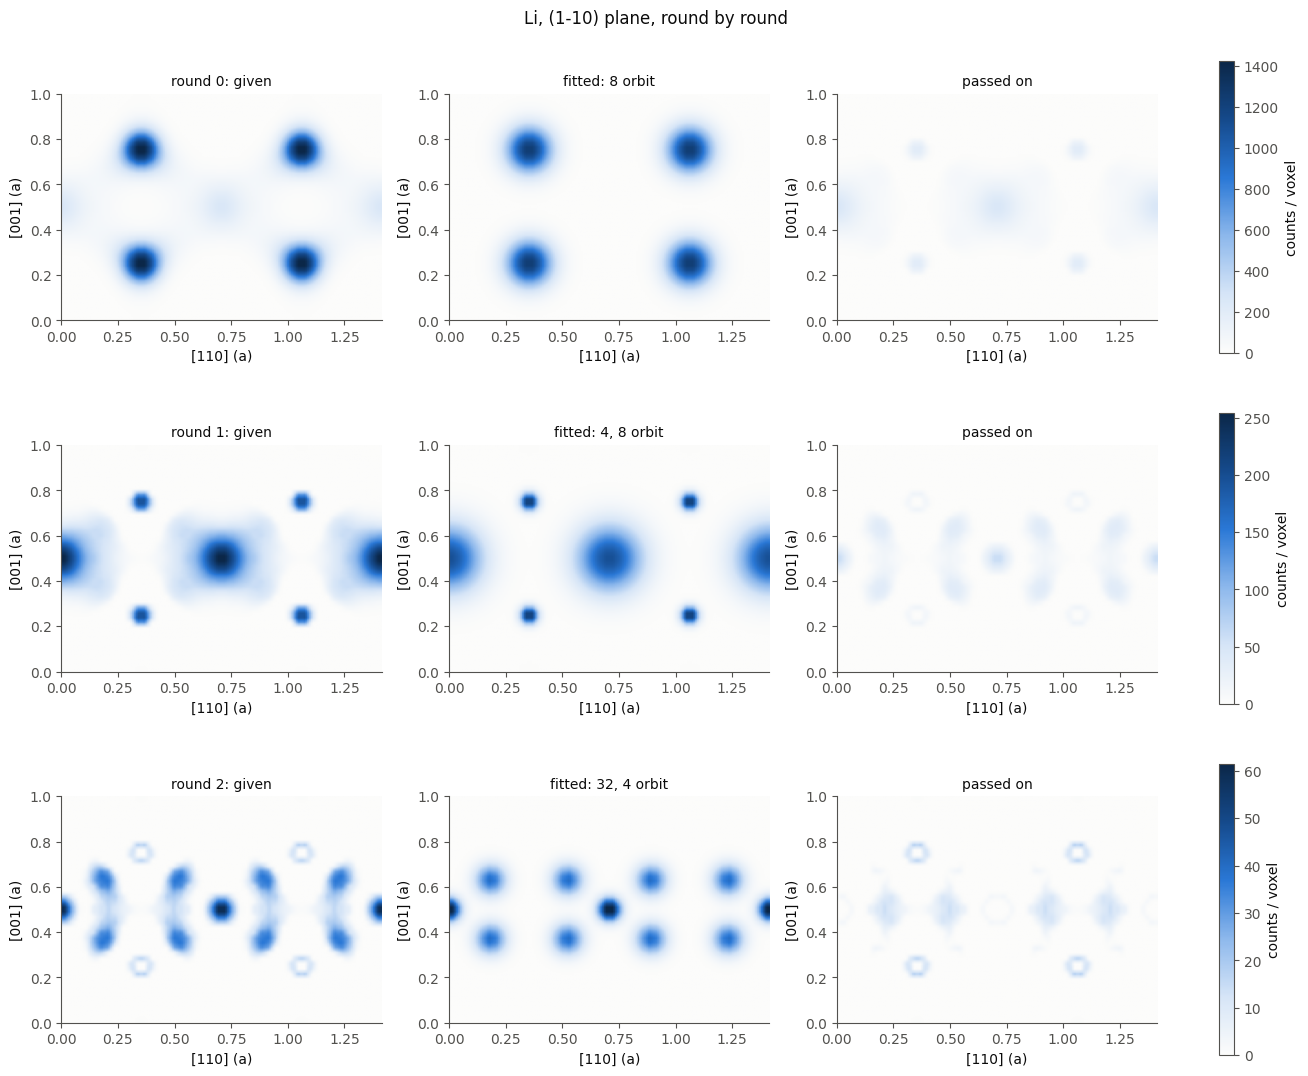

In [6]:
view = {k: DIAGONAL_PLANE[k] for k in ('origin', 'e1', 'e2')}
axes = {k: DIAGONAL_PLANE[k] for k in ('extent', 'labels')}

li_rounds = history['Li']
fig, axs = plt.subplots(
    len(li_rounds), 3, figsize=(13, 3.6 * len(li_rounds)), layout='constrained'
)
for row, round_ in zip(axs, li_rounds):
    given = round_.fit.observed_density
    fitted = given.sum() * round_.fit.model_density
    images = [plane(given, **view), plane(fitted, **view), plane(round_.residual, **view)]
    vmax = max(image.max() for image in images)
    titles = (
        f'round {round_.round}: given',
        f'fitted: {", ".join(str(s.multiplicity) for s in round_.fit.sites)} orbit',
        'passed on',
    )
    for ax, image, title in zip(row, images, titles):
        im = show(ax, image, vmin=0, vmax=vmax, title=title, **axes)
    fig.colorbar(im, ax=row, shrink=0.85, label='counts / voxel')
fig.suptitle('Li, (1-10) plane, round by round', color=INK)
plt.show()

Along the body diagonal the rounds stack up. The observed density is in black; each colour
adds one round's Gaussians on top of the rounds before it.

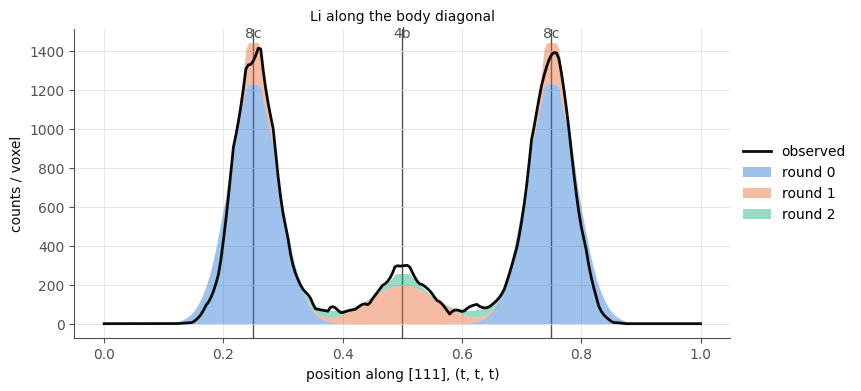

In [7]:
li_folded = fold_supercell(traj.filter('Li').to_volume(resolution=RESOLUTION).data, SUPERCELL)

fig, ax = plt.subplots(figsize=(8.5, 3.8), layout='constrained')
t, observed_line = line(li_folded, (0, 0, 0), (1, 1, 1))
ax.plot(t, observed_line, color=INK, label='observed')
stacked = np.zeros_like(observed_line)
for round_, color in zip(li_rounds, (BLUE, ORANGE, AQUA)):
    fitted = round_.fit.observed_density.sum() * round_.fit.model_density
    below = stacked.copy()
    stacked = stacked + line(fitted, (0, 0, 0), (1, 1, 1))[1]
    ax.fill_between(
        t, below, stacked, color=color, alpha=0.45, lw=0, label=f'round {round_.round}'
    )
for x, label in [(0.25, '8c'), (0.5, '4b'), (0.75, '8c')]:
    ax.axvline(x, color=MUTED, lw=1, zorder=0)
    ax.text(x, observed_line.max() * 1.04, label, ha='center', color=MUTED)
ax.set(
    xlabel='position along [111], (t, t, t)',
    ylabel='counts / voxel',
    title='Li along the body diagonal',
)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

The rounds peel the density apart, and neither the peaks nor the sites were chosen by hand:

- **Round 0** takes off the tetrahedral sites. To also cover the octahedral density it has
  to widen the 8c Gaussian (*U*<sub>iso</sub> 0.25 Å²), so the observed 8c maxima stick out
  above it. What it passes on is the octahedral site (faint next to 8c in the input, the
  strongest feature now) and those 8c tips.
- **Round 1** fits both. What it passes on is a set of lobes around the octahedral site,
  pointing at the tetrahedral sites.
- **Round 2** fits those lobes as the 32f orbit, with a little more on 4b. That round
  explains 2.9 % of the density, less than `min_explained`, so Li stops there.

Along the body diagonal: round 0 alone falls short at the 8c maxima and has nothing at 4b.
Round 1 fills the octahedral bump and the 8c tips, and round 2 fills the shoulders between
them.

## 4. One structure out of the rounds

Each round fitted only what the rounds before it left over. It gave a widened 8c Gaussian
the octahedral density to carry, and took the 8c tips back in round 1. So the rounds together
are the *list of sites*, not the structure. One last fit refines all of them together
against the untouched, symmetrised Li density. A site that turned up again in a later
round, like 8c in round 1, is counted once. A site with free coordinates, like 32f's x,
has them refined.

In [8]:
spacegroup = li_rounds[-1].spacegroup  # all Li rounds found Fm-3m in the same setting


def same_orbit(position, other):
    delta = wyckoff_orbit(spacegroup, position) - other
    return np.any(np.all(np.abs(delta - np.round(delta)) < 1e-3, axis=1))


sites = []
for round_ in li_rounds:
    for site in round_.fit.sites:
        if not any(same_orbit(s['position'], site.position) for s in sites):
            free = len(site_free_directions(spacegroup, site.position)) > 0
            sites.append({'specie': 'Li', 'position': site.position, 'free_position': free})

joint = fit_density_model(
    li_folded, spacegroup, sites, cell_length=a, coarsen=2, maxiter=100, popsize=15, seed=0
)
display(sites_table(joint))

first = li_rounds[0].fit
pd.DataFrame(
    {
        'round 0 only (8c)': {
            'orbits': len(first.sites),
            'parameters': len(first.params),
            'R1-like': round(first.metrics['r1_like'], 3),
        },
        'all rounds, refined together': {
            'orbits': len(joint.sites),
            'parameters': len(joint.params),
            'R1-like': round(joint.metrics['r1_like'], 3),
        },
    }
)

,specie,multiplicity,position,density fraction,site occupancy,U_iso (Å²),split (Å)
0,Li,8,"(0.25, 0.75, 0.25)",0.5913,0.5913,0.1588,NaN
1,Li,4,"(0.0, 0.0, 0.5)",0.1935,0.3870,0.4276,NaN
2,Li,32,"(0.3333, 0.3332, 0.6668)",0.2152,0.0538,0.1827,0.45


,round 0 only (8c),"all rounds, refined together"
orbits,1.000,3.000
parameters,1.000,6.000
R1-like,0.502,0.067


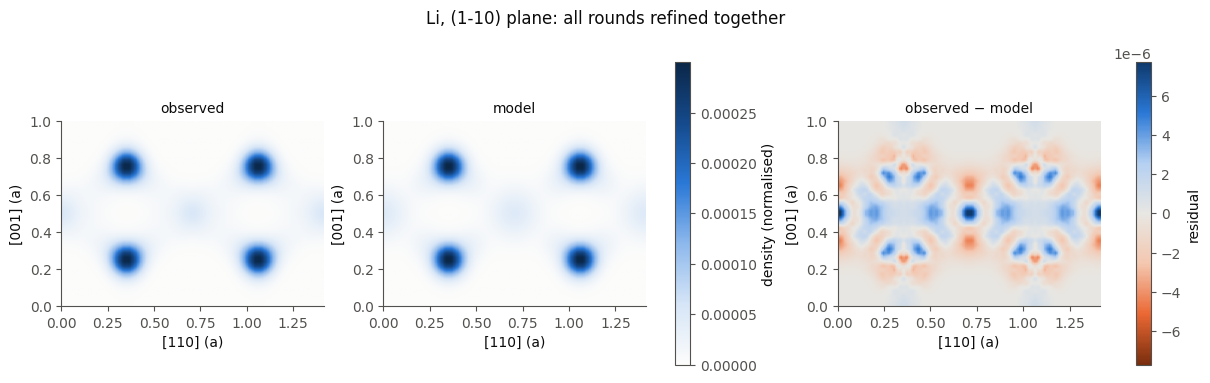

In [9]:
compare_maps(
    joint.observed_density,
    joint.model_density,
    **DIAGONAL_PLANE,
    title='Li, (1-10) plane: all rounds refined together',
)
plt.show()

Refined together, the three orbits fit the Li density to R1 = 0.067. That compares with 0.50
for the Crystallizer's 8c site alone, and 0.15 for the best model built by hand in the
companion notebook (32f split off 8c, plus 4b). The eight Li atoms per cell are shared out
as:

- **8c**, tetrahedral: 59 % of the density, site occupancy 0.59, *U*<sub>iso</sub> 0.16 Å².
- **4b**, octahedral: 19 %, occupancy 0.39, *U*<sub>iso</sub> 0.43 Å².
- **32f (x, x, x)**, x = ⅓: 22 %, occupancy 0.05, *U*<sub>iso</sub> 0.18 Å². This orbit
  sits 1.0 Å from the tetrahedral centre along ⟨111⟩, a third of the way to the octahedral
  site, on the path Li takes between the two. The joint fit moved it 0.45 Å (`split`) from
  where round 2 put it. Round 2 was fitting a leftover; the joint fit fits the whole density.

The misfit that remains is a few percent of the peak density. It sits at 4b, where the
density is a narrow peak on a broad base (as the companion notebook found), and in rings
around 8c, whose density is not quite Gaussian.

## 5. Against the paper

Table I of the manuscript (*Refinement of the Average Structure of Dynamically Disordered
α-Lithium Sulfate from Molecular Dynamics*) is the model built by hand from this kind of
density: Fm-3m, S on 4a, Li on 8c + 4b, O on 96j (0, y, z) with ⅙ occupancy. Its text adds
that the tetrahedral site is split four ways (32f), but gives no x. The table below puts the
loop's result next to it. For Li the loop's numbers are those of the joint refinement
(section 4); the Table I "fractions" are the share of the Li density on each site
(occupancy × multiplicity / 8).

In [10]:
by_mult = {site.multiplicity: site for site in joint.sites}
tet, oct_, path = by_mult[8], by_mult[4], by_mult[32]
s_fit = history['S'][0].fit

comparison = pd.DataFrame(
    [
        ('space group', li_rounds[0].fit.spacegroup_symbol, 'Fm-3m'),
        ('S site', f'{s_fit.sites[0].multiplicity}a', '4a'),
        ('S U_iso (Å²)', round(s_fit.sites[0].u_iso, 3), 0.134),
        ('Li on 8c (fraction)', round(tet.occupancy, 3), 0.866),
        ('Li on 4b (fraction)', round(oct_.occupancy, 3), round(0.268 * 4 / 8, 3)),
        ('Li on 32f (fraction)', round(path.occupancy, 3), '4-way split of 8c, x not given'),
        ('Li 32f x', round(float(path.position[0]) % 1, 3), '–'),
        ('Li 8c U_iso (Å²)', round(tet.u_iso, 3), 0.214),
        ('Li 4b U_iso (Å²)', round(oct_.u_iso, 3), 0.634),
        ('O site', 'none (P1, left alone)', '96j (0, 0.1011, 0.1779), occ. ⅙'),
        ('O U (Å²)', '–', '0.182 (U_eq, anisotropic)'),
    ],
    columns=['quantity', 'this loop', 'Table I'],
).set_index('quantity')
comparison

,this loop,Table I
quantity,,
space group,Fm-3m,Fm-3m
S site,4a,4a
S U_iso (Å²),0.126,0.134
Li on 8c (fraction),0.591,0.866
Li on 4b (fraction),0.194,0.134
Li on 32f (fraction),0.215,"4-way split of 8c, x not given"
Li 32f x,0.333,–
Li 8c U_iso (Å²),0.159,0.214
Li 4b U_iso (Å²),0.428,0.634


- **Symmetry and framework agree.** The loop finds Fm-3m for S and for every Li round
  without being told, and S on 4a. Its S is at (½, 0, ½), which in Fm-3m is the origin
  plus a centring translation.
- **The Li sites are the paper's, plus the path between them.** The loop finds 8c and 4b by
  itself, and a 32f orbit, as the paper does. But its 32f is a different feature: x = ⅓
  puts it 1.0 Å from the tetrahedral centre, a third of the way to the octahedral site.
  The paper's (and the companion density notebook's) split 32f stays close to 8c
  (x ≈ 0.28, 0.35 Å off), and describes the shape of the tetrahedral site. The loop
  instead peels 8c off first, so what is left for 32f is the density *between* the sites.
- **More Li off the tetrahedral site.** Table I has 13.4 % of the Li density on 4b (the
  text says 13.8 %); the loop has 19 % on 4b and another 22 % on the path. Part of that is
  the data, not the method: on this cache the paper's own `fit_densities_Li.py` gives 70 %
  on 8c and 30 % on 4b, not 87 / 13 (see the companion density notebook). Table I was made
  from a different state of the analysis.
- **Narrower sites.** The loop's widths are all below Table I: *U*<sub>iso</sub> 0.16
  against 0.21 Å² on 8c and 0.43 against 0.63 Å² on 4b. With a separate orbit for the
  path density, neither Gaussian has to stretch to cover it. S, which has no such
  competition, is close (0.126 against 0.134 Å², where the reference script also gives
  0.126 on this cache).
- **O is where the paper goes further.** Table I's 96j model with an anisotropic *U* is
  what makes the paper: six superposed D₂d sulfate orientations. The O density has no
  separate peaks, so the loop cannot find any site for it and correctly stops. The
  [density crystallography notebook](density_crystallography.ipynb) recovers 96j at
  (0, 0.099, 0.184) once the group and a starting direction are given by hand.

## 6. Summary

- **One call, then only plots.** The only choices that go in are `framework_species` and the
  numerical settings. The loop finds the space group, the sites and their widths itself,
  species by species. For Li it recovers the 8c + 4b model that the companion notebook
  builds by hand, and adds the 32f orbit on the conduction path.
- **The rounds are a list of sites, not a structure.** Each round fits what the rounds
  before it left over, so the result is only as good as the last joint refinement
  (section 4).
- **It only finds what has peaks.** A species whose density has no separate peaks, O here,
  crystallizes as P1 and is left alone (`max_orbits`). Its group and starting site have to
  come from elsewhere, as in the companion notebook.